In [2]:

import csv
import logging
import sys
import time

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import typer

from torch.amp import GradScaler, autocast
from torch.optim import Adam
from torch.utils.data import DataLoader as TorchDataLoader, random_split
from torch_geometric.loader import DataLoader, DataLoader as PyGDataLoader
from tqdm import tqdm

from qqe.experiments.plotting import plot_training_curves
from qqe.GNN.physics_aware_NN import GNN, QuantumCircuitGraphDataset, Regressor

# from qqe.GNN.training.datasets import build_loaders, build_loaders_NN
from qqe.GNN.training.train_config import TrainConfig
from qqe.GNN.training.utils import (
    FamilyFeatureProjector,
    ProjectedDatasetWrapper,
    cache_root_paths,
    collect_files_path,
    evaluate_loss,
    unpack_supervised_batch,
)
from qqe.utils import configure_logger

logger = logging.getLogger(__name__)

In [3]:
class GlobalMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)

In [4]:
class PaddedGraphDatasetWrapper:
    def __init__(self, dataset, target_dim: int | None = None):
        self.dataset = dataset
        self.target_dim = target_dim or self._compute_max_dim()

    def _compute_max_dim(self) -> int:
        max_dim = 0
        for i in range(len(self.dataset)):
            data = self.dataset[i]
            if hasattr(data, "x") and data.x.dim() > 1:
                max_dim = max(max_dim, data.x.shape[1])
        return max_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx]

        if hasattr(data, "x") and data.x.shape[1] < self.target_dim:
            # Pad the feature matrix with zeros
            out = data.clone()
            pad_size = self.target_dim - data.x.shape[1]
            out.x = F.pad(out.x, (0, pad_size), value=0)
            return out
        return data

In [5]:
class GlobalTargetDatasetWrapper:
    def __init__(self, dataset, constant_target: float | None = None):
        self.dataset = dataset
        self.constant_target = constant_target

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        data = self.dataset[idx]

        g = getattr(data, "global_features", None)
        if g is None:
            raise ValueError("Sample is missing 'global_features'.")
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        if self.constant_target is not None:
            y_tensor = torch.tensor(self.constant_target, dtype=torch.float32)
        else:
            y = getattr(data, "y", None)
            if y is None:
                y_tensor = torch.tensor(float("nan"), dtype=torch.float32)
            elif torch.is_tensor(y):
                y_tensor = y.flatten()[0].to(torch.float32)
            else:
                y_tensor = torch.tensor(float(y), dtype=torch.float32)

        return g, y_tensor

In [6]:
def build_loaders_NN(
    pt_paths: list[str],
    *,
    batch_size: int = 32,
    seed: int = 42,
    train_split: float = 0.8,
    val_split: float = 0.1,
    global_feature_variant: str = "binned",
    node_feature_variant: str | None = None,
    family_projection: str | None = None,
):
    suffix = (
        f"{global_feature_variant}"
        f"__backend_{node_feature_variant or 'none'}"
        f"_familyproj_{family_projection or 'none'}"
    )
    root = cache_root_paths(pt_paths, suffix=suffix)

    base_dataset = QuantumCircuitGraphDataset(
        root=root,
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_variant,
    )

    if len(base_dataset) < 3:
        raise RuntimeError("Dataset too small for train/val/test splitting.")

    working_dataset = base_dataset
    if family_projection is not None:
        projector = FamilyFeatureProjector(
            family=family_projection,
            all_gate_keys=base_dataset.all_gate_keys,
        )
        working_dataset = ProjectedDatasetWrapper(
            working_dataset,
            transform=projector,
        )

    nn_dataset = GlobalTargetDatasetWrapper(working_dataset)
    sample0_g, _ = nn_dataset[0]


    global_in_dim = int(sample0_g.numel())

    generator = torch.Generator().manual_seed(seed)
    primary_train_len = max(1, int(len(nn_dataset) * train_split))
    test_len = max(1, len(nn_dataset) - primary_train_len)

    while primary_train_len + test_len > len(nn_dataset):
        primary_train_len -= 1

    primary_train_dataset, test_ds = random_split(
        nn_dataset,
        [primary_train_len, test_len],
        generator=generator,
    )

    val_len = max(1, int(len(primary_train_dataset) * val_split))
    real_train_len = max(1, len(primary_train_dataset) - val_len)

    train_ds, val_ds = random_split(
        primary_train_dataset,
        [real_train_len, val_len],
        generator=generator,
    )

    pin_mem = torch.cuda.is_available()

    return (
        TorchDataLoader(
            train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_mem
        ),
        TorchDataLoader(
            val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_mem
        ),
        TorchDataLoader(
            test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_mem
        ),
        global_in_dim,
        base_dataset,
    )


In [7]:
def _amp_device_type() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

def build_loss(loss_type: str, huber_delta: float = 1.0) -> nn.Module:
    loss_type = loss_type.lower()
    if loss_type == "mse":
        return nn.MSELoss()
    if loss_type == "l1":
        return nn.L1Loss()
    if loss_type == "huber":
        return nn.HuberLoss(delta=huber_delta)
    raise ValueError(f"Unsupported loss type: {loss_type}")


@dataclass
class TrainHistory:
    train_loss: list[float]
    val_loss: list[float]
    lr: list[float]

def _run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    scaler: GradScaler,
    device: torch.device,
    *,
    use_amp: bool = True,
    grad_clip: float | None = 5.0,
    epoch_idx: int = 1,
    num_epochs: int = 1,
    show_progress: bool = True,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
) -> tuple[float, float]:
    model.train()
    amp_device = _amp_device_type()

    total_loss = 0.0
    total_graphs = 0
    batch_count = 0

    start_time = time.time()
    last_heartbeat = start_time

    train_iter = tqdm(
        loader,
        desc=f"Epoch {epoch_idx}/{num_epochs}",
        leave=False,
        disable=not show_progress,
        file=sys.stdout,
    )

    for batch in train_iter:
        model_input, y, batch_size = unpack_supervised_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=amp_device,
            enabled=(use_amp and device.type == "cuda"),
        ):
            pred = model(model_input).view(-1).float()
            mask = torch.isfinite(y)
            if mask.sum() == 0:
                continue
            loss = loss_fn(pred[mask], y[mask])

        if not torch.isfinite(loss):
            logger.warning("Skipping batch with non-finite loss.")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * batch_size
        total_graphs += batch_size
        batch_count += 1

        running_loss = total_loss / max(1, total_graphs)

        if show_progress:
            train_iter.set_postfix(
                {
                    "loss": f"{running_loss:.4f}",
                    "graphs": total_graphs,
                },
            )

        if log_every_n_batches > 0 and batch_count % log_every_n_batches == 0:
            elapsed = time.time() - start_time
            batches_per_sec = batch_count / max(elapsed, 1e-3)
            remaining_batches = len(loader) - batch_count
            eta_secs = remaining_batches / max(batches_per_sec, 1e-3)

            logger.debug(
                f"Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | "
                f"ETA {eta_secs:.1f}s | {batches_per_sec:.2f} batch/s",
            )

        if heartbeat_secs > 0:
            now = time.time()
            if now - last_heartbeat >= heartbeat_secs:
                elapsed = time.time() - start_time
                print(
                    f"[Heartbeat] Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                    f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | graphs {total_graphs}",
                )
                last_heartbeat = now

    epoch_loss = total_loss / max(1, total_graphs)
    elapsed = time.time() - start_time
    return epoch_loss, elapsed


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    device: str | None = None,
    loss_type: str = "huber",   # "mse" | "huber" | "l1"
    huber_delta: float = 1.0,
    grad_clip: float | None = 5.0,
    early_stopping_patience: int = 15,
    early_stopping_min_delta: float = 0.0,
    use_amp: bool = True,
    scheduler: str = "none",    # "none" | "plateau"
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 300.0,
) -> tuple[nn.Module, TrainHistory, torch.device]:
    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Using device: {dev}")
    model = model.to(dev)

    loss_fn = build_loss(loss_type=loss_type, huber_delta=huber_delta)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == "plateau":
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,
        )
    elif scheduler == "none":
        lr_scheduler = None
    else:
        raise ValueError("scheduler must be 'none' or 'plateau'")

    scaler = GradScaler(
        device=_amp_device_type(),
        enabled=(use_amp and dev.type == "cuda"),
    )

    history = TrainHistory(train_loss=[], val_loss=[], lr=[])

    best_val_loss = float("inf")
    best_state_dict = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        print(f"-------- EPOCH {epoch:03d} --------")

        train_loss, train_time = _run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scaler=scaler,
            device=dev,
            use_amp=use_amp,
            grad_clip=grad_clip,
            epoch_idx=epoch,
            num_epochs=epochs,
            show_progress=show_progress,
            log_every_n_batches=log_every_n_batches,
            heartbeat_secs=heartbeat_secs,
        )

        print(f"Training complete ({train_time:.1f}s) | running validation...")

        val_start_time = time.time()
        val_loss = evaluate_loss(
            model=model,
            loader=val_loader,
            device=dev,
            loss_fn=loss_fn,
            use_amp=use_amp,
            show_progress=show_val_progress,
        )
        val_time = time.time() - val_start_time

        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        history.train_loss.append(float(train_loss))
        history.val_loss.append(float(val_loss))
        history.lr.append(current_lr)

        epoch_time = time.time() - epoch_start_time

        print(
            f"Losses | train {train_loss:.6f} | val {val_loss:.6f} | "
            f"lr {current_lr:.2e} | time train={train_time:.1f}s "
            f"val={val_time:.1f}s total={epoch_time:.1f}s",
        )

        if epoch_time_warning_secs > 0 and epoch_time > epoch_time_warning_secs:
            logger.warning(
                f"Epoch {epoch} took {epoch_time:.1f}s "
                f"(>{epoch_time_warning_secs:.0f}s threshold).",
            )

        improved = val_loss + early_stopping_min_delta < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            logger.debug(f"New best validation loss: {best_val_loss:.6f}")
        else:
            bad_epochs += 1
            logger.debug(
                f"No improvement: patience {bad_epochs}/{early_stopping_patience}",
            )
            if bad_epochs >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch:03d} | "
                    f"best val {best_val_loss:.6f} | "
                    f"patience exhausted ({bad_epochs}/{early_stopping_patience})",
                )
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, dev

In [8]:
def run_training(
    cfg: TrainConfig,
    model_hparams: dict | None = None,
    train_hparams: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = (
        build_loaders(
            data_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family_projection,
        )
    )

    default_model_hparams = {
        "gnn_hidden": 32,
        "gnn_heads": 8,
        "global_hidden": 16,
        "reg_hidden": 16,
        "num_layers": 3,
        "dropout_rate": 0.1,
    }
    if model_hparams:
        default_model_hparams.update(model_hparams)

    model = GNN(
        node_in_dim=node_in_dim,
        global_in_dim=global_in_dim,
        gnn_hidden=default_model_hparams["gnn_hidden"],
        gnn_heads=default_model_hparams["gnn_heads"],
        global_hidden=default_model_hparams["global_hidden"],
        reg_hidden=default_model_hparams["reg_hidden"],
        num_layers=default_model_hparams["num_layers"],
        dropout_rate=default_model_hparams["dropout_rate"],
    )

    default_train_hparams = {
        "weight_decay": 0.0,
        "grad_clip": 5.0,
        "early_stopping_patience": 15,
        "early_stopping_min_delta": 0.0,
    }
    if train_hparams:
        default_train_hparams.update(train_hparams)

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
        weight_decay=default_train_hparams["weight_decay"],
        grad_clip=default_train_hparams["grad_clip"],
        early_stopping_patience=default_train_hparams["early_stopping_patience"],
        early_stopping_min_delta=default_train_hparams["early_stopping_min_delta"],
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return (
        model,
        hist,
        test_loss,
        node_in_dim,
        global_in_dim,
        base_dataset,
        default_model_hparams,
    )

In [9]:
def run_training_NN(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
    ):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )
    if model_type == "nn":
        pass
    elif model_type == "MLP":
        model = GlobalMLP(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    elif model_type == "regressor":
        model = Regressor(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return model, hist, test_loss, global_in_dim, base_dataset


def _filter_paths_by_depth(
    pt_paths: list[str],
    *,
    min_layers: int | None = None,
    max_layers: int | None = None,
    ):
    if min_layers is None and max_layers is None:
        return pt_paths
    if min_layers is not None and min_layers < 0:
        raise ValueError("min_layers must be >= 0")
    if max_layers is not None and max_layers < 0:
        raise ValueError("max_layers must be >= 0")
    if min_layers is not None and max_layers is not None and min_layers > max_layers:
        raise ValueError("min_layers must be <= max_layers")

    filtered = []
    for path in pt_paths:
        obj = torch.load(path, map_location="cpu", weights_only=True)
        meta = obj.get("meta", {}) or {}
        n_layers = meta.get("n_layers", None)
        if n_layers is None:
            continue
        if min_layers is not None and n_layers < min_layers:
            continue
        if max_layers is not None and n_layers > max_layers:
            continue
        filtered.append(path)
    return filtered


def run_training_NN_deep(
    cfg: TrainConfig,
    *,
    min_layers: int,
    model_type: str | None = None,
    model_params: dict | None = None,
    ):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")
    data_paths = _filter_paths_by_depth(data_paths, min_layers=min_layers)
    if not data_paths:
        raise RuntimeError(f"No data paths found with n_layers >= {min_layers}.")

    print(f"Using {len(data_paths)} data paths after filtering by min_layers={min_layers}.")
    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )
    if model_type == "nn":
        pass
    elif model_type == "MLP":
        model = GlobalMLP(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    elif model_type == "regressor":
        model = Regressor(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return model, hist, test_loss, global_in_dim, base_dataset


def run_training_NN_shallow(
    cfg: TrainConfig,
    *,
    max_layers: int,
    model_type: str | None = None,
    model_params: dict | None = None,
    ):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")
    data_paths = _filter_paths_by_depth(data_paths, max_layers=max_layers)
    if not data_paths:
        raise RuntimeError(f"No data paths found with n_layers <= {max_layers}.")

    print(f"Using {len(data_paths)} data paths after filtering by max_layers={max_layers}.")
    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )
    if model_type == "nn":
        pass
    elif model_type == "MLP":
        model = GlobalMLP(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    elif model_type == "regressor":
        model = Regressor(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return model, hist, test_loss, global_in_dim, base_dataset

In [10]:
def _resolve_model_save_path(base_path: str, allow_overwrite: bool = False) -> str:
    """Return a non-colliding checkpoint path unless overwrite is explicitly allowed."""
    path = Path(base_path)
    if allow_overwrite or not path.exists():
        return str(path)

    stem = path.stem
    suffix = path.suffix
    parent = path.parent
    counter = 1

    while True:
        candidate = parent / f"{stem}_v{counter}{suffix}"
        if not candidate.exists():
            print(
                "Model checkpoint already exists at %s. Saving to %s instead.",
                path,
                candidate,
            )
            return str(candidate)
        counter += 1

In [11]:
def run(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    model, hist, test_loss, global_in_dim, base_dataset = run_training_NN(cfg, model_type=model_type, model_params=model_params)
    node_in_dim = None
    model_hparams = {
        "gnn_hidden": None,
        "gnn_heads": None,
        "global_hidden": None,
        "reg_hidden": None,
        "num_layers": None,
        "dropout_rate": cfg.dropout_rate if hasattr(cfg, "dropout_rate") else 0.0,
    }

    plot_training_curves(
        hist,
        title=f"{model_type.upper()} SRE regression",
        save_fig=True,
        fig_path=f"outputs/figures/training_curves/training_curves_{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}.png",
    )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_config": {
            "node_in_dim": node_in_dim or None,
            "global_in_dim": global_in_dim,
            "gnn_hidden": model_hparams["gnn_hidden"],
            "gnn_heads": model_hparams["gnn_heads"],
            "global_hidden": model_hparams["global_hidden"],
            "reg_hidden": model_hparams["reg_hidden"],
            "num_layers": model_hparams["num_layers"],
            "dropout_rate": model_hparams["dropout_rate"],
        },
        "train_config": asdict(cfg),
        "feature_config": {
            "global_feature_variant": cfg.global_feature_variant,
            "node_feature_backend_variant": cfg.node_feature_backend_variant,
            "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
            "family_projection": (
                cfg.family if cfg.training_mode == "per_family" else None
            ),
        },
        "final_metrics": {
            "test_loss": float(test_loss),
        },
    }

    # model_save_path = _resolve_model_save_path(
    #         f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
    #         allow_overwrite=allow_overwrite,
    #     )
    model_save_path = f"dummy_{model_type}_model.pt"
    torch.save(checkpoint, model_save_path)
    print("Saved model checkpoint to %s", model_save_path)

In [12]:
cfg = TrainConfig(
    epochs=30,
    lr=1e-3,
    loss_type="mse",
    batch_size=32,
    training_mode="global",
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    seed=42,
    train_split=0.8,
    val_split=0.1,
    show_progress=True,
    show_val_progress=False,
    log_batch_loss_every=10,
    heartbeat=60.0,
    epoch_warning=300.0,
)

model, hist, test_loss, global_in_dim, base_dataset = run_training_NN(cfg, model_type="MLP", model_params={"hidden_dim": 128, "dropout_rate": 0.1})

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/30:  84%|████████▍ | 3802/4500 [04:00<00:44, 15.66it/s, loss=0.7398, graphs=121696][Heartbeat] Epoch 1 batch 3803/4500 | loss 0.739766 | elapsed 240.1s | graphs 121696
Training complete (286.0s) | running validation...                                         


Epoch 1 took 315.7s (>300s threshold).


Losses | train 0.670934 | val 0.190017 | lr 1.00e-03 | time train=286.0s val=29.6s total=315.7s
-------- EPOCH 002 --------
Epoch 2/30:  87%|████████▋ | 3906/4500 [04:00<00:39, 14.92it/s, loss=0.2101, graphs=125024][Heartbeat] Epoch 2 batch 3907/4500 | loss 0.210094 | elapsed 240.1s | graphs 125024
Training complete (279.0s) | running validation...                                         


Epoch 2 took 306.8s (>300s threshold).


Losses | train 0.204858 | val 0.492882 | lr 1.00e-03 | time train=279.0s val=27.8s total=306.8s
-------- EPOCH 003 --------
Epoch 3/30:  92%|█████████▏| 4152/4500 [04:00<00:23, 14.69it/s, loss=0.1394, graphs=132928][Heartbeat] Epoch 3 batch 4154/4500 | loss 0.139393 | elapsed 240.1s | graphs 132928
Training complete (262.3s) | running validation...                                         
Losses | train 0.137879 | val 0.939808 | lr 1.00e-03 | time train=262.3s val=30.1s total=292.3s
-------- EPOCH 004 --------
Epoch 4/30:  85%|████████▌ | 3826/4500 [04:00<00:49, 13.68it/s, loss=0.1172, graphs=122496][Heartbeat] Epoch 4 batch 3828/4500 | loss 0.117152 | elapsed 240.1s | graphs 122496
Training complete (284.3s) | running validation...                                         


Epoch 4 took 313.3s (>300s threshold).


Losses | train 0.117306 | val 0.780174 | lr 1.00e-03 | time train=284.3s val=29.0s total=313.3s
-------- EPOCH 005 --------
Epoch 5/30:  84%|████████▎ | 3764/4500 [04:00<00:49, 15.02it/s, loss=0.1090, graphs=120480][Heartbeat] Epoch 5 batch 3765/4500 | loss 0.109050 | elapsed 240.1s | graphs 120480
Training complete (288.0s) | running validation...                                         


Epoch 5 took 316.7s (>300s threshold).


Losses | train 0.108026 | val 0.661379 | lr 1.00e-03 | time train=288.0s val=28.7s total=316.7s
-------- EPOCH 006 --------
Epoch 6/30:  91%|█████████▏| 4115/4500 [04:00<00:24, 15.55it/s, loss=0.0986, graphs=131744][Heartbeat] Epoch 6 batch 4117/4500 | loss 0.098643 | elapsed 240.2s | graphs 131744
Training complete (264.9s) | running validation...                                         
Losses | train 0.098541 | val 0.782419 | lr 1.00e-03 | time train=264.9s val=29.1s total=294.0s
-------- EPOCH 007 --------
Epoch 7/30:  92%|█████████▏| 4129/4500 [04:00<00:23, 15.82it/s, loss=0.0959, graphs=132192][Heartbeat] Epoch 7 batch 4131/4500 | loss 0.095899 | elapsed 240.2s | graphs 132192
Training complete (264.0s) | running validation...                                         
Losses | train 0.095744 | val 0.802851 | lr 5.00e-04 | time train=264.0s val=27.9s total=291.9s
-------- EPOCH 008 --------
Epoch 8/30:  96%|█████████▌| 4317/4500 [04:00<00:11, 15.61it/s, loss=0.0752, graphs=138176][

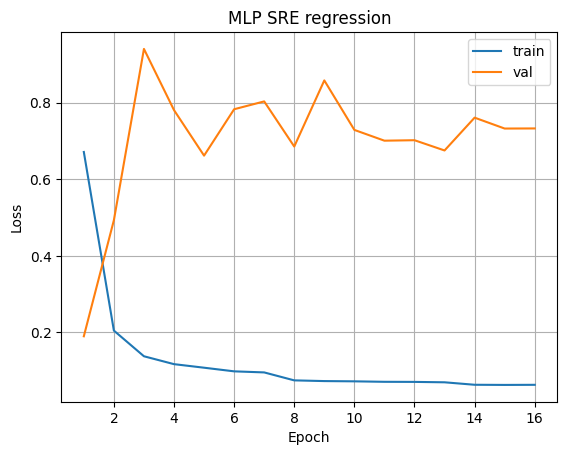

Saved model checkpoint to %s dummy_MLP_model.pt


In [13]:
model_type="MLP"
loss_type=cfg.loss_type
training_mode=cfg.training_mode
family = cfg.family if cfg.training_mode == "per_family" else None

node_in_dim = None
model_hparams = {
    "gnn_hidden": None,
    "gnn_heads": None,
    "global_hidden": None,
    "reg_hidden": None,
    "num_layers": None,
    "dropout_rate": cfg.dropout_rate if hasattr(cfg, "dropout_rate") else 0.0,
}

plot_training_curves(
    hist,
    title=f"{model_type.upper()} SRE regression",
    save_fig=True,
    fig_path=f"outputs/figures/training_curves/training_curves_{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}.png",
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "node_in_dim": node_in_dim or None,
        "global_in_dim": global_in_dim,
        "gnn_hidden": model_hparams["gnn_hidden"],
        "gnn_heads": model_hparams["gnn_heads"],
        "global_hidden": model_hparams["global_hidden"],
        "reg_hidden": model_hparams["reg_hidden"],
        "num_layers": model_hparams["num_layers"],
        "dropout_rate": model_hparams["dropout_rate"],
    },
    "train_config": asdict(cfg),
    "feature_config": {
        "global_feature_variant": cfg.global_feature_variant,
        "node_feature_backend_variant": cfg.node_feature_backend_variant,
        "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
        "family_projection": (
            cfg.family if cfg.training_mode == "per_family" else None
        ),
    },
    "final_metrics": {
        "test_loss": float(test_loss),
    },
}

# model_save_path = _resolve_model_save_path(
#         f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
#         allow_overwrite=allow_overwrite,
#     )
model_save_path = f"dummy_{model_type}_model.pt"
torch.save(checkpoint, model_save_path)
print("Saved model checkpoint to %s", model_save_path)

In [14]:
cfg = TrainConfig(
    epochs=30,
    lr=1e-3,
    loss_type="mse",
    batch_size=32,
    training_mode="per_family",
    family="random",
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    seed=42,
    train_split=0.8,
    val_split=0.1,
    show_progress=True,
    show_val_progress=False,
    log_batch_loss_every=10,
    heartbeat=60.0,
    epoch_warning=300.0,
)

model, hist, test_loss, global_in_dim, base_dataset = run_training_NN(cfg, model_type="MLP", model_params={"hidden_dim": 32, "dropout_rate": 0.0})

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/30:  81%|████████  | 906/1125 [01:00<00:14, 15.47it/s, loss=1.0646, graphs=29024][Heartbeat] Epoch 1 batch 907/1125 | loss 1.064623 | elapsed 60.0s | graphs 29024
Training complete (74.9s) | running validation...                                         
Losses | train 0.875250 | val 0.083696 | lr 1.00e-03 | time train=74.9s val=8.3s total=83.2s
-------- EPOCH 002 --------
Epoch 2/30:  79%|███████▊  | 884/1125 [01:00<00:14, 16.14it/s, loss=0.1516, graphs=28352][Heartbeat] Epoch 2 batch 886/1125 | loss 0.151590 | elapsed 60.0s | graphs 28352
Training complete (75.8s) | running validation...                                         
Losses | train 0.148027 | val 0.118908 | lr 1.00e-03 | time train=75.8s val=8.1s total=83.9s
-------- EPOCH 003 --------
Epoch 3/30:  75%|███████▌  | 846/1125 [01:00<00:20, 13.61it/s, loss=0.1183, graphs=27136][Heartbeat] Epoch 3 batch 848/1125 | loss 0.118283 | elapsed 60.0s | graphs 27136
Training complet

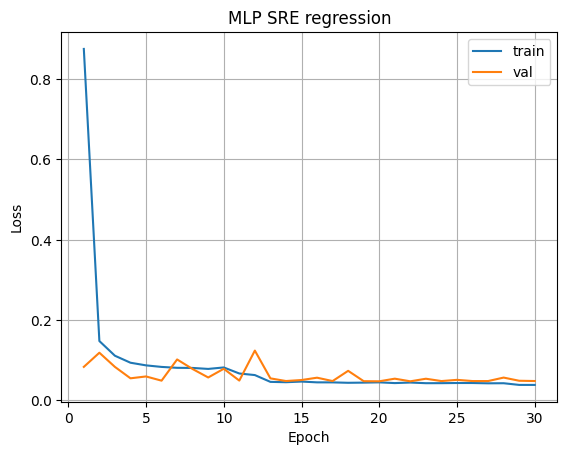

Saved model checkpoint to %s dummy_MLP_model2.pt


In [15]:
model_type="MLP"
loss_type=cfg.loss_type
training_mode=cfg.training_mode
family = cfg.family if cfg.training_mode == "per_family" else None

node_in_dim = None
model_hparams = {
    "gnn_hidden": None,
    "gnn_heads": None,
    "global_hidden": None,
    "reg_hidden": None,
    "num_layers": None,
    "dropout_rate": cfg.dropout_rate if hasattr(cfg, "dropout_rate") else 0.0,
}

plot_training_curves(
    hist,
    title=f"{model_type.upper()} SRE regression",
    save_fig=True,
    fig_path=f"outputs/figures/training_curves/training_curves_{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}.png",
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "node_in_dim": node_in_dim or None,
        "global_in_dim": global_in_dim,
        "gnn_hidden": model_hparams["gnn_hidden"],
        "gnn_heads": model_hparams["gnn_heads"],
        "global_hidden": model_hparams["global_hidden"],
        "reg_hidden": model_hparams["reg_hidden"],
        "num_layers": model_hparams["num_layers"],
        "dropout_rate": model_hparams["dropout_rate"],
    },
    "train_config": asdict(cfg),
    "feature_config": {
        "global_feature_variant": cfg.global_feature_variant,
        "node_feature_backend_variant": cfg.node_feature_backend_variant,
        "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
        "family_projection": (
            cfg.family if cfg.training_mode == "per_family" else None
        ),
    },
    "final_metrics": {
        "test_loss": float(test_loss),
    },
}

# model_save_path = _resolve_model_save_path(
#         f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
#         allow_overwrite=allow_overwrite,
#     )
model_save_path = f"dummy_{model_type}_model2.pt"
torch.save(checkpoint, model_save_path)
print("Saved model checkpoint to %s", model_save_path)

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/30:  88%|████████▊ | 994/1125 [01:00<00:08, 16.31it/s, loss=1.2356, graphs=31840][Heartbeat] Epoch 1 batch 995/1125 | loss 1.235564 | elapsed 60.0s | graphs 31840
Training complete (67.8s) | running validation...                                         
Losses | train 1.113290 | val 0.093079 | lr 1.00e-03 | time train=67.8s val=7.0s total=74.8s
-------- EPOCH 002 --------
Epoch 2/30:  89%|████████▊ | 996/1125 [01:00<00:07, 16.46it/s, loss=0.1379, graphs=31936][Heartbeat] Epoch 2 batch 998/1125 | loss 0.137860 | elapsed 60.1s | graphs 31936
Training complete (67.6s) | running validation...                                         
Losses | train 0.136328 | val 0.087697 | lr 1.00e-03 | time train=67.6s val=7.0s total=74.6s
-------- EPOCH 003 --------
Epoch 3/30:  89%|████████▊ | 998/1125 [01:00<00:07, 16.76it/s, loss=0.1557, graphs=32000][Heartbeat] Epoch 3 batch 1000/1125 | loss 0.155668 | elapsed 60.0s | graphs 32000
Training comple

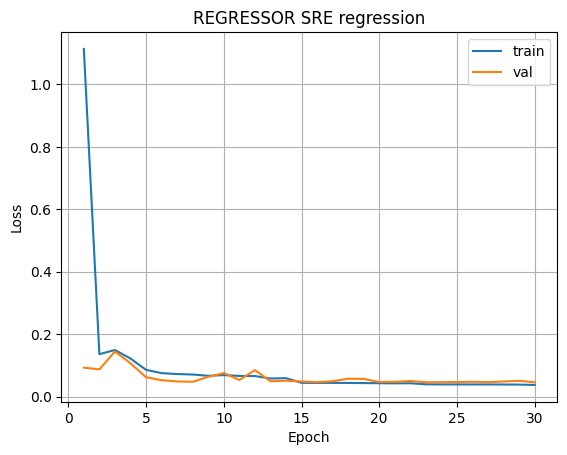

Saved model checkpoint to %s dummy_regressor_model3.pt


In [16]:
cfg = TrainConfig(
    epochs=30,
    lr=1e-3,
    loss_type="mse",
    batch_size=32,
    training_mode="per_family",
    family="random",
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    seed=42,
    train_split=0.8,
    val_split=0.1,
    show_progress=True,
    show_val_progress=False,
    log_batch_loss_every=10,
    heartbeat=60.0,
    epoch_warning=300.0,
)

model, hist, test_loss, global_in_dim, base_dataset = run_training_NN(cfg, model_type="regressor", model_params={"hidden_dim": 32, "dropout_rate": 0.0})

model_type="regressor"
loss_type=cfg.loss_type
training_mode=cfg.training_mode
family = cfg.family if cfg.training_mode == "per_family" else None

node_in_dim = None
model_hparams = {
    "gnn_hidden": None,
    "gnn_heads": None,
    "global_hidden": None,
    "reg_hidden": None,
    "num_layers": None,
    "dropout_rate": cfg.dropout_rate if hasattr(cfg, "dropout_rate") else 0.0,
}

plot_training_curves(
    hist,
    title=f"{model_type.upper()} SRE regression",
    save_fig=True,
    fig_path=f"outputs/figures/training_curves/training_curves_{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}.png",
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "node_in_dim": node_in_dim or None,
        "global_in_dim": global_in_dim,
        "gnn_hidden": model_hparams["gnn_hidden"],
        "gnn_heads": model_hparams["gnn_heads"],
        "global_hidden": model_hparams["global_hidden"],
        "reg_hidden": model_hparams["reg_hidden"],
        "num_layers": model_hparams["num_layers"],
        "dropout_rate": model_hparams["dropout_rate"],
    },
    "train_config": asdict(cfg),
    "feature_config": {
        "global_feature_variant": cfg.global_feature_variant,
        "node_feature_backend_variant": cfg.node_feature_backend_variant,
        "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
        "family_projection": (
            cfg.family if cfg.training_mode == "per_family" else None
        ),
    },
    "final_metrics": {
        "test_loss": float(test_loss),
    },
}

# model_save_path = _resolve_model_save_path(
#         f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
#         allow_overwrite=allow_overwrite,
#     )
model_save_path = f"dummy_{model_type}_model3.pt"
torch.save(checkpoint, model_save_path)
print("Saved model checkpoint to %s", model_save_path)

### Shallow model training

In [34]:
# Shallow circuits: keep only samples with n_layers <= shallow_max_layers.
shallow_max_layers = 35
shallow_cfg = TrainConfig(
    epochs=30,
    lr=1e-3,
    loss_type="mse",
    batch_size=32,
    training_mode="global",
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    seed=42,
    train_split=0.8,
    val_split=0.1,
    show_progress=True,
    show_val_progress=False,
    log_batch_loss_every=10,
    heartbeat=60.0,
    epoch_warning=300.0,
 )
shallow_model, shallow_hist, shallow_test_loss, shallow_in_dim, shallow_base_ds = run_training_NN_shallow(
    shallow_cfg,
    max_layers=shallow_max_layers,
    model_type="MLP",
    model_params={"hidden_dim": 128, "dropout_rate": 0.1},
 )
print(f"Shallow test loss: {shallow_test_loss:.6f} | global_in_dim={shallow_in_dim}")

Using 68000 data paths after filtering by max_layers=35.
Using device: cuda
-------- EPOCH 001 --------
Epoch 1/30:  84%|████████▎ | 1281/1530 [01:00<00:12, 20.21it/s, loss=0.9054, graphs=41056][Heartbeat] Epoch 1 batch 1283/1530 | loss 0.905356 | elapsed 60.0s | graphs 41056
Training complete (71.6s) | running validation...                                         
Losses | train 0.830828 | val 0.347989 | lr 1.00e-03 | time train=71.6s val=6.8s total=78.4s
-------- EPOCH 002 --------
Epoch 2/30:  81%|████████  | 1243/1530 [01:00<00:13, 21.12it/s, loss=0.3861, graphs=39808][Heartbeat] Epoch 2 batch 1244/1530 | loss 0.386145 | elapsed 60.0s | graphs 39808
Training complete (73.5s) | running validation...                                         
Losses | train 0.380373 | val 0.247791 | lr 1.00e-03 | time train=73.5s val=7.0s total=80.5s
-------- EPOCH 003 --------
Epoch 3/30:  91%|█████████ | 1385/1530 [01:00<00:06, 23.74it/s, loss=0.3041, graphs=44352][Heartbeat] Epoch 3 batch 1386/1530 

Shallow test loss: 0.260570 | global_in_dim=508


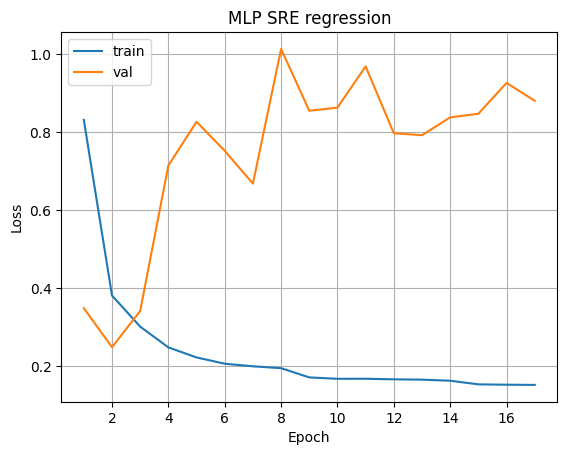

Saved model checkpoint to %s shallow_MLP_model.pt


In [38]:
model_type="MLP"
model_hparams={"hidden_dim": 128, "dropout_rate": 0.1}
node_in_dim = None
model_hparams = {
    "gnn_hidden": None,
    "gnn_heads": None,
    "global_hidden": None,
    "reg_hidden": None,
    "num_layers": None,
    "dropout_rate": shallow_cfg.dropout_rate if hasattr(shallow_cfg, "dropout_rate") else 0.0,
}

plot_training_curves(
    shallow_hist,
    title=f"{model_type.upper()} SRE regression",
    save_fig=True,
    fig_path="training_curves",
)

checkpoint = {
    "model_state_dict": shallow_model.state_dict(),
    "model_config": {
        "node_in_dim": shallow_in_dim or None,
        "global_in_dim": shallow_in_dim,
        "gnn_hidden": model_hparams["gnn_hidden"],
        "gnn_heads": model_hparams["gnn_heads"],
        "global_hidden": model_hparams["global_hidden"],
        "reg_hidden": model_hparams["reg_hidden"],
        "num_layers": model_hparams["num_layers"],
        "dropout_rate": model_hparams["dropout_rate"],
    },
    "train_config": asdict(shallow_cfg),
    "feature_config": {
        "global_feature_variant": shallow_cfg.global_feature_variant,
        "node_feature_backend_variant": shallow_cfg.node_feature_backend_variant,
        "all_gate_keys": getattr(shallow_base_ds, "all_gate_keys", None),
        "family_projection": (
            shallow_cfg.family if shallow_cfg.training_mode == "per_family" else None
        ),
    },
    "final_metrics": {
        "test_loss": float(shallow_test_loss),
    },
}

# model_save_path = _resolve_model_save_path(
#         f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
#         allow_overwrite=allow_overwrite,
#     )
model_save_path = f"shallow_{model_type}_model.pt"
torch.save(checkpoint, model_save_path)
print("Saved model checkpoint to %s", model_save_path)

### Deep model training

In [39]:
# Deep circuits: keep only samples with n_layers >= deep_min_layers.
deep_min_layers = 35
deep_cfg = TrainConfig(
    epochs=30,
    lr=1e-3,
    loss_type="mse",
    batch_size=32,
    training_mode="global",
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    seed=42,
    train_split=0.8,
    val_split=0.1,
    show_progress=True,
    show_val_progress=False,
    log_batch_loss_every=10,
    heartbeat=60.0,
    epoch_warning=300.0,
 )
deep_model, deep_hist, deep_test_loss, deep_in_dim, deep_base_ds = run_training_NN_deep(
    deep_cfg,
    min_layers=deep_min_layers,
    model_type="MLP",
    model_params={"hidden_dim": 128, "dropout_rate": 0.1},
 )
print(f"Deep test loss: {deep_test_loss:.6f} | global_in_dim={deep_in_dim}")

Using 132000 data paths after filtering by min_layers=35.
Using device: cuda
-------- EPOCH 001 --------
Epoch 1/30:  75%|███████▌  | 2232/2970 [02:00<00:53, 13.70it/s, loss=0.9562, graphs=71456][Heartbeat] Epoch 1 batch 2233/2970 | loss 0.956250 | elapsed 120.1s | graphs 71456
Training complete (168.8s) | running validation...                                        
Losses | train 0.800820 | val 0.377518 | lr 1.00e-03 | time train=168.8s val=19.7s total=188.5s
-------- EPOCH 002 --------
Epoch 2/30: 100%|█████████▉| 2965/2970 [03:00<00:00, 15.19it/s, loss=0.2027, graphs=94944][Heartbeat] Epoch 2 batch 2967/2970 | loss 0.202685 | elapsed 180.1s | graphs 94944
Training complete (180.3s) | running validation...                                        
Losses | train 0.202600 | val 0.749612 | lr 1.00e-03 | time train=180.3s val=20.3s total=200.6s
-------- EPOCH 003 --------
Epoch 3/30: 100%|█████████▉| 2963/2970 [03:00<00:00, 14.25it/s, loss=0.0924, graphs=94880][Heartbeat] Epoch 3 batch 2

Deep test loss: 0.375178 | global_in_dim=508


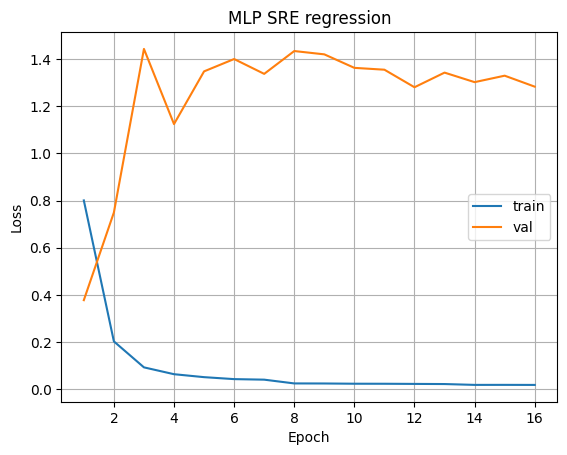

Saved model checkpoint to %s deep_MLP_model.pt


In [40]:
model_type="MLP"
model_hparams={"hidden_dim": 128, "dropout_rate": 0.1}
node_in_dim = None
model_hparams = {
    "gnn_hidden": None,
    "gnn_heads": None,
    "global_hidden": None,
    "reg_hidden": None,
    "num_layers": None,
    "dropout_rate": shallow_cfg.dropout_rate if hasattr(shallow_cfg, "dropout_rate") else 0.0,
}

plot_training_curves(
    deep_hist,
    title=f"{model_type.upper()} SRE regression",
    save_fig=True,
    fig_path="training_curves",
)

checkpoint = {
    "model_state_dict": deep_model.state_dict(),
    "model_config": {
        "node_in_dim": deep_in_dim or None,
        "global_in_dim": deep_in_dim,
        "gnn_hidden": model_hparams["gnn_hidden"],
        "gnn_heads": model_hparams["gnn_heads"],
        "global_hidden": model_hparams["global_hidden"],
        "reg_hidden": model_hparams["reg_hidden"],
        "num_layers": model_hparams["num_layers"],
        "dropout_rate": model_hparams["dropout_rate"],
    },
    "train_config": asdict(deep_cfg),
    "feature_config": {
        "global_feature_variant": deep_cfg.global_feature_variant,
        "node_feature_backend_variant": deep_cfg.node_feature_backend_variant,
        "all_gate_keys": getattr(deep_base_ds, "all_gate_keys", None),
        "family_projection": (
            deep_cfg.family if deep_cfg.training_mode == "per_family" else None
        ),
    },
    "final_metrics": {
        "test_loss": float(deep_test_loss),
    },
}

# model_save_path = _resolve_model_save_path(
#         f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
#         allow_overwrite=allow_overwrite,
#     )
model_save_path = f"deep_{model_type}_model.pt"
torch.save(checkpoint, model_save_path)
print("Saved model checkpoint to %s", model_save_path)